# Taller en clase · Calidad de datos: diagnosticar, limpiar y medir
**Ciencia de Datos · Ingeniería Industrial · CORHUILA 2026‑B · Semana 9**

El 26 de septiembre diste tus primeros pasos: cargaste un CSV, lo graficaste y le hiciste una limpieza mínima. Hoy vas un paso más allá. Vas a **medir** la calidad de un registro de la planta, **corregir cada problema con la técnica adecuada**, **dejar constancia** de lo que hiciste y **comprobar con números** que los datos quedaron mejor.

Al terminar sabrás:

1. Diagnosticar la calidad de una tabla con cinco dimensiones: **completitud, unicidad, consistencia, formato y validez**.
2. Quitar **duplicados** y **homologar** textos escritos de varias formas.
3. Convertir **tipos de datos**: números guardados como texto y fechas en dos formatos.
4. Normalizar **unidades** (°F → °C).
5. Decidir entre **eliminar o imputar** un dato faltante.
6. Distinguir un dato **atípico** de un dato **imposible**.
7. Medir la calidad **antes y después** y llevar una **bitácora de limpieza**.
8. Responder la pregunta del negocio con datos confiables.

> **Todo el código ya está escrito y funciona de principio a fin.** Tu trabajo es ejecutar cada celda en orden (**Shift + Enter**), leer el resultado y responder las preguntas. Si algo falla, casi siempre es porque se saltó una celda: usa **Ejecutar todo** (*Run All*) desde el inicio. Si ejecutaste una celda de limpieza dos veces y tus cifras ya no coinciden con los puntos de control, usa **Entorno de ejecución → Reiniciar y ejecutar todo**.

| Símbolo | Qué significa |
|---|---|
| 👉 | La línea clave del paso: la que hace el trabajo importante |
| 🧠 | Pregunta para ti: haz doble clic en la celda de texto que sigue y escribe tu respuesta |
| ✅ | Punto de control: compara tu resultado con el número indicado |

## Parte 0 · Preparar el entorno
Dos celdas dejan todo listo:

1. La primera revisa que estén las librerías **pandas** (tablas) y **matplotlib** (gráficos). En Colab ya vienen; en VS Code las instala sola la primera vez si faltan (tarda un minuto).
2. La segunda **crea el archivo de datos** del taller, `registro_produccion.csv`. Los datos viajan dentro del cuaderno, comprimidos, para que el taller funcione aunque no haya internet. **No tienes que entender esa celda**: solo ejecútala.

In [1]:
import importlib.util, subprocess, sys

faltan = [lib for lib in ["pandas", "matplotlib"] if importlib.util.find_spec(lib) is None]
if faltan:                                   # solo pasa la primera vez en VS Code
    print("Instalando:", faltan)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltan])

import pandas as pd                 # tablas de datos
import matplotlib.pyplot as plt     # gráficos

plt.rcParams["figure.figsize"] = (9, 4)     # tamaño de los gráficos
pd.set_option("display.max_columns", 20)    # mostrar todas las columnas
print("pandas", pd.__version__, "· listo para trabajar")

pandas 3.0.5 · listo para trabajar


In [2]:
# Crea el archivo registro_produccion.csv a partir de los datos comprimidos (no hace falta entenderla)
import base64, gzip

DATOS = (
    "H4sIAAAAAAACCpVaTY5cNw7e9ykKtVa3RVK/S2MwwGyS2cwFGnYHycJ24rQPMkeZM+RiQ1KqalJPD+gggBGjPkuUSH7kR71f"
    "Xj79+hxef3z/+i18ef7jx29fn8Pv3799/vHpt8/Pf4bPL7+8fHr98e1P/v/Xly+/v3x/ZuzzA0Ysj7E/xhp+ev7rf8/8r356"
    "jBAAC4RA+QlOIBggthyghBMAXWSRGHoP1J/iCSrxMpn/aIHgCR9i/RD7B4GG/zx///wyjYkFA0YxJ9l17hA2hpfh/QKlp7yF"
    "EP/aW4AK4ZoopOsWxZZAK7LXlSgUB/r526dfbwZh7AH4YOTv5w5Rg3pACj0yxBxrQL6oQRBjSHzy8tS2q4g1qHdM8am8Qdri"
    "KyhNTO7JrtMWb1GNAZuYTCcgsYiviG+Imj1XWxyW+FhAYlO3oFfjMIQaEOVkzmzjsF6qLpK9zQMxr6fLBfAVxR1m3g8bbEOw"
    "OTcBMKTKmdMWgmIpqSfBn/gOIYm+HEhXKVsI70HYNYYjx/Ad0teUqkV9idaavriJd5ugcgISixrvlQV0tp3kFaBmBNqTdZ9X"
    "mSFJILSFyAKZ1JP4VLcQtia1HvIaxt27SbytG2ULcSnFjsAUsPszOV/lqL6K/m6sr1JLIWm+1C0khcZcIru8/c4h5h2Vge82"
    "icPzCUgclbsGMDC3Qbzn95JPCTh8PSv5lcRRvJc4KhpHMcg6CgsziRjUtwgxB0Bv2Ka3hYgxHKGZ76by2Y3F1k+xtpkNbiPr"
    "pxI6n9yFjEWImyqzdRk3s4MoFReFxJNVxBQmNT4QNmsKLJ6KHHoIYk1/ANg5QepU6ZpSYH0Oi6cwC10tPofFUxwZozaALSAM"
    "G3d4GUaRkJ/yRT1ipkmEM8vjFiI5zhtx+WQqpgPkcqMd4bfuGYUxPq2ipFWrfhmfVuOmuzfG+Yt34SMdIP/+x7/+eY9iXgUE"
    "Yi4Q10o1/HUCwNC4WxichScYMYYrVKrshRLy9QSWQq95kgVHO67RrlfDpC0uLzbv0PtJODSKK9sRcplpxVUVeMNkacmuw7Zk"
    "UK4ge6x33DD6alZpxnGzJ3JNR1JXMqT8HSq2G/EemW8loZi7t0VXiWKL93Zavc0hPLKTHiCdZKc0msMePFlJWwHhLb5Ha1Fa"
    "s1MYI8vhnU2+keyhCR3jFiE3yAa3hbCTp1H2N+/Eidm2EHZ3F4cqTfSrxVhvxjbKs1CtuRzfQoLW3ujNta4CXsU3CxYgFCGh"
    "x+1htTSa186kxVnk4wlIbOVCJs0UWCbJLDa+8n+XaQ+VpC2t7bj8SlLrUtJ2HuwNZucoSBpflL1FzlOEA+N4NtsWsjOz8fm5"
    "4qXtKmkUxSXS80KgRfp4it7YAbnMq+lNGT/6S3aOqhIyAslbiDaRWViCc8rsVBZXEeuckVP1BCRXU7UCtSa9STnpTVCCuEio"
    "n22n14Nh6Y5h0Wb8dwmLZK+w+B6SyQRpCYo3iCohtraIUCzbRSRoUANZecKcybmq1+mGbFdxKSW1OR7u2DGxeGppii1ENaJ2"
    "bLyKuZZVQXPq6akTnwnqCftJ/mJaCsx9pcu9OORQ45Bl+6XEHlaTNx0Nex0NU2pnb7ereEwFQ0f3LUT7yCJNQ0jA/tztlGaD"
    "AwszeQ0tl9iZJKMjSS+iY67zTHkLoVEVl3TwElr8mUNL1pJ2mHbE2T3XE5Aa0yYB5hOQuIo7E7ngs81U0xe9GwlTaDtH9Tpq"
    "okvNdsipAUlbiJgynOX1M3j9TKA18yruulqQK1V9pPiyjnUUcVHkYN/+rGVBhgrc3vl7cf1+41xZhNmqoDWqaOnku8sW8VNN"
    "2ge4jmKR0J2D71EktLu/fuj3b6MpsiCnzPhYiMNV0L0zbwYRtWO98xoaOLa4N+FKtYdwB98EpnOpeLUYx4C1h4O5jv+ERfvB"
    "FMd/Rdtr5ZEdRHzVddzh+A8XbabFjNdzFOBBGsZd+c9SNh60mSDAV2kDutzKJx56XwTvLA4LXJIGvTLDDgpBc0HolRmyspD2"
    "OJtrthAdkeXZ3KGFWFdRbFMlwxYicSOtOvphBi6yIY1iFU82Ev4TzbUUKzwKs9FqWoWCeGjV0zS5noBojEZJ4jRbdYa4Dj24"
    "8GV/tHcwHKKvZ3xBWHz1RK/gJLF0nGNjB70/Wfpz3nB1xS0kXcTcEtoSFXhIPWnMwF+z86cEe/SDEfTSC7m9I+0295A0Z8/Z"
    "tzBMvc6ffTK2nQZ5jPBkurFb3IHmEDYrcztBpKCvd182brugHNZxiZeLXk7yKXMapnQn0surDQnp3ua4Z7eTTpZ6eOSw0CnX"
    "DiOxx8DVmeSdSSqItj9rhak6iWRj+xZDs55FP8+0EGEJwDky4Qjf6mMY6+CtkzoT0TIGH/MkY88qoqWZkpGH7SpwEdEyqfA6"
    "EL2CTpwIUkAc+VkJLcmSaY476hajYcX5lKTh3y+jfVvyPvD6WV4HJJns7MtCJFxIdUdzzJeWQaQYsVCaV9BQceabyYB8aPaL"
    "GCvVma4WZuSxWNSaFEY3k/dryd0U1PeGtGz48a//fvz54/12irKjqw1eQ1OP85FqD9FHoRvtpy2Ehv5lrmZ23EPSEFVMJN02"
    "Fbio6FJmnY9/i6mzJ1CZU9CSdk5ndxktdD/uxLzogTzHneZ6jzI7Dn+C86fPuwvzLEzq4+02QlssknqIXk4etVvR2cpqk/Nm"
    "GevkEwiOYB4pQVuIxruYotVZzlVOxFs6THqc1OYcT7nNCX7cYsQcbJPR8xZCY8zD6XeVh8nrFqTFl0gzUJ8C2glPYs7z8IZv"
    "VwkHMKYn0QbzQcJpRvjHXVxFHLHlsp07fzN9PxfhNF6trfJ8D4m1Y0O6vBq+L37a4T0h6euPM/itvupcI0995ZaxFqeS9RkZ"
    "/DJOYxSaxbFuIUr/VVpo9ugekubDbF0ueBWEMjITPqVTkD62jGbIke76pJp4ewnGYmO+M327a8bRf5BfydVHWaxpgpnPB3B5"
    "VJVGMAthli1EB7tRfCbinbYYNSfP1wm3jHVXkwBatDAur6pDrI1X1X4crE0BlmBRB335UCGFNt4wKZ61MvH2XPV2JDq8q0pr"
    "lb108qBbm7zMJWl9V6XRBI/26g10cR8qjC7NzY8oLhMxmjU7byE00o+ab4osJA2ma16ckn9Yzdoy6UDMcCG5t9WmUeFfiWh9"
    "Wq1yNVh5J+MJl1q5h2I6U4hiwOKr0uZw/Qwk6ox0etnvOXoAzUiWMlpOV5pDOrBDhwFyBTCPbyzKCQTHGBnkCplVr1uQdAic"
    "ePpRSd0izIAOPcSp91amFO5byKTB8XCQtxAaH1ew+7hbgS1Ev3+h+ShgbFnVe0pa1SmegnA88pgZ3gFyG32T+cDiABKFIC8C"
    "qz3OUaCv5G8suUD0SZ4mJceHiB8g+ibkFjWqM/b7iHySl0PQHi1fLcg3nl0/9yhbAI7Jh8yymt/IvYfKR0ggKdWstb5a6Zn9"
    "KnTIqTqrfX6IdF9n/QCozhblbCWpVsJ/aDq0A0g/5tA6LISSrhbmnm+6kZcbCI45MoKbES8gGopZ2SuHugdpfyFP5fIu1S3E"
    "JVZW1fdGlAvkJhT6mBSYa/QzTNG54g7crqIkWGd3Gt/nsXfEz/8BPDhx+IUpAAA="
)
with open("registro_produccion.csv", "wb") as archivo:
    archivo.write(gzip.decompress(base64.b64decode(DATOS)))

# Un CSV es texto plano: así se ven sus primeras líneas por dentro
with open("registro_produccion.csv", encoding="utf-8") as archivo:
    for _ in range(4):
        print(archivo.readline().rstrip())

fecha,turno,maquina,producidas,defectuosas,temperatura
2026-09-07,Mañana,M-01,1261,,35.1
2026-09-07,Mañana,M-02,1085,16,
2026-09-07,Mañana,M-03 ,1260,99,39.0


✅ **Punto de control:** debes ver la línea de encabezados `fecha,turno,maquina,producidas,defectuosas,temperatura` y tres filas de datos. Cada coma separa una columna; por eso se llama *Comma‑Separated Values*.

## Parte 1 · El caso
La misma planta de empaques del Huila que ya conoces tiene **4 máquinas** en dos líneas de producción y trabaja **3 turnos**. Al final de cada turno, el supervisor digita en una hoja de cálculo compartida cuántas unidades produjo cada máquina, cuántas salieron defectuosas y a qué temperatura cerró la máquina. Hay tres supervisores, cada uno con sus costumbres, y nadie revisa lo que se digita.

| Máquina | Nombre | Línea | Instalada en |
|---|---|---|---|
| M‑01 | Extrusora A | Línea 1 · Película | 2019 |
| M‑02 | Extrusora B | Línea 1 · Película | 2021 |
| M‑03 | Selladora C | Línea 2 · Bolsas | 2012 |
| M‑04 | Cortadora D | Línea 2 · Bolsas | 2023 |

El registro cubre **4 semanas**, del lunes 7 de septiembre al sábado 3 de octubre, de lunes a sábado. La gerencia pregunta:

> **¿Qué máquina y qué turno tienen la mayor tasa de defectos? ¿A cuál le hacemos mantenimiento primero?**

### Diccionario de datos
| Columna | Qué significa | Tipo esperado |
|---|---|---|
| `fecha` | Día del registro, formato `aaaa-mm-dd` | Fecha |
| `turno` | Mañana, Tarde o Noche | Texto (3 valores) |
| `maquina` | Código de la máquina: M‑01 a M‑04 | Texto (4 valores) |
| `producidas` | Unidades fabricadas en el turno | Número entero |
| `defectuosas` | Unidades que no pasaron control de calidad | Número entero |
| `temperatura` | Temperatura de la máquina al cerrar el turno, en °C | Número decimal |

### Reglas del negocio (con ellas vamos a validar)
- La capacidad máxima de una máquina es de **1.800 unidades por turno**.
- Las defectuosas van de **0** hasta el número de unidades producidas.
- El sensor de temperatura mide entre **15 y 60 °C**.
- Solo existen **4 máquinas** y **3 turnos**.

🧠 **Responde:** antes de mirar los datos, ¿qué errores esperas encontrar en una hoja que digitan a mano tres personas distintas durante cuatro semanas? Escribe al menos tres.

*respuesta:

Espero filas repetidas (alguien digita dos veces el mismo turno), códigos de máquina y turnos escritos de formas distintas (M-01, M1, m-01; Mañana, manana), fechas en formatos diferentes, datos vacíos porque se les olvidó anotar, números mal digitados (un cero de más o columnas intercambiadas) y decimales con coma en vez de punto. Por dimensión: los vacíos afectan la **completitud**, los repetidos la **unicidad**, los códigos mal escritos la **consistencia**, las fechas mezcladas el **formato** y los números imposibles o en otra unidad la **validez**.


## Parte 2 · Cargar y dar una primera mirada
`pd.read_csv()` lee el archivo y lo convierte en un **DataFrame**, la tabla de pandas. Lo guardamos en la variable `df` (por *data frame*).

**Regla de oro de hoy:** `df` es el **original** y no lo vamos a modificar. Así siempre podremos comparar el antes y el después.

In [3]:
df = pd.read_csv("registro_produccion.csv")     # 👉 carga el archivo en una tabla
print("Filas y columnas:", df.shape)            # (filas, columnas)

Filas y columnas: (297, 6)


✅ **Punto de control:** `(297, 6)`. Son 297 registros y 6 columnas. Ojo: 4 semanas × 6 días × 3 turnos × 4 máquinas daría 288 registros. ¿De dónde salen los demás? Lo descubriremos.

In [4]:
df.head(10)      # las primeras 10 filas

,fecha,turno,maquina,producidas,defectuosas,temperatura
0,2026-09-07,Mañana,M-01,1261,NaN,35.1
1,2026-09-07,Mañana,M-02,1085,16.0,NaN
2,2026-09-07,Mañana,M-03,1260,99.0,39.0
3,2026-09-07,Mañana,M-04,1054,18.0,31.2
4,07/09/2026,Tarde,M-01,1062,20.0,35.4
5,2026-09-07,Tarde,M-02,1105,12.0,34.5
6,2026-09-07,Tarde,M-03,1298,171.0,"43,4"
7,2026-09-07,Tarde,M-04,1186,20.0,"33,6"
8,2026-09-07,Noche,M-01,1209,19.0,33.1
9,2026-09-07,Noche,M-02,1109,23.0,90.1


Las primeras filas casi siempre se ven bien. Una **muestra al azar** suele mostrar más variedad, y más problemas:

In [5]:
df.sample(12, random_state=7)     # 12 filas al azar (random_state fija el azar para que todos veamos las mismas)

,fecha,turno,maquina,producidas,defectuosas,temperatura
199,2026-09-25,MAÑANA,M-04,1276,14.0,30.7
3,2026-09-07,Mañana,M-04,1054,18.0,31.2
216,26/09/2026,Tarde,M-04,1034,17.0,31.3
284,03/10/2026,Mañana,M-02,1107,21.0,30.7
125,2026-09-18,Mañana,M-04,1126,11.0,30.5
243,2026-09-29,Noche,M-01,18,1295.0,32.2
78,2026-09-14,Tarde,M-01,1069,8.0,34.2
99,2026-09-16,Mañana,M-02,1177,27.0,88.0
37,2026-09-10,Mañana,M-02,1159,13.0,31.0
161,2026-09-22,Mañana,M-04,1082,5.0,30.7


🧠 **Responde:** en la muestra al azar, ¿ves algo raro? Fíjate en cómo están escritas las fechas, las máquinas, los turnos y las temperaturas.

Respuesta:* Sí. Hay turnos escritos en mayúsculas (`MAÑANA`), fechas con barras (`26/09/2026`) mezcladas con fechas con guiones, una temperatura de 88 °C que no es posible para la planta, y una fila con solo 18 unidades producidas y 1.295 defectuosas, que parece tener las columnas intercambiadas.


### `info()`: el tipo de cada columna
`info()` muestra, por columna, cuántos valores **no vacíos** tiene y de qué **tipo** es:

| Tipo que muestra pandas | Qué significa |
|---|---|
| `int64` | Números enteros |
| `float64` | Números con decimales (o enteros con algún vacío) |
| `object` o `str` | **Texto** (según tu versión de pandas verás uno u otro) |

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fecha        297 non-null    str    
 1   turno        297 non-null    str    
 2   maquina      297 non-null    str    
 3   producidas   297 non-null    int64  
 4   defectuosas  287 non-null    float64
 5   temperatura  291 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 14.1 KB


Lee el resultado con calma:

- Hay **297 entradas** (filas), pero `defectuosas` y `temperatura` tienen **menos** valores no vacíos: **faltan datos**.
- `defectuosas` aparece como `float64` aunque las unidades son enteras. Cuando una columna de números tiene vacíos, pandas la guarda como decimal, porque el vacío (`NaN`, *Not a Number*) es un valor decimal especial.
- `temperatura` aparece como **texto** (`object` o `str`) aunque debería ser un número. Basta con **un solo** valor que pandas no reconozca como número para que trate toda la columna como texto.

In [7]:
df.describe()    # estadísticas de las columnas numéricas: conteo, promedio, mínimo, máximo...

,producidas,defectuosas
count,297.000000,287.000000
mean,1246.811448,37.648084
std,826.802056,121.228811
min,16.000000,-67.000000
25%,1105.000000,15.500000
50%,1196.000000,20.000000
75%,1275.000000,29.500000
max,11320.000000,1303.000000


`describe()` solo resume columnas **numéricas**. Por eso `temperatura` ni siquiera aparece: pandas la considera texto.

🧠 **Responde:** mira los valores `min` y `max` de `producidas` y `defectuosas`. ¿Cuáles violan las reglas del negocio de la Parte 1? ¿Por qué?

*Respuesta:* El máximo de `producidas` es 11.320, muy por encima de la capacidad de 1.800 unidades por turno (parece un cero de más). El mínimo de `defectuosas` es −67, y no puede haber defectuosas negativas. El máximo de `defectuosas` es 1.303, que es mayor que lo que normalmente se produce, y el mínimo de `producidas` es 16, muy bajo: parecen filas con las columnas cruzadas.


## Parte 3 · Diagnóstico de calidad (antes de tocar nada)
Un buen analista **primero mide y después limpia**. Si no mides el antes, no puedes demostrar que mejoraste. Vamos a revisar la tabla con cinco **dimensiones de calidad**:

| Dimensión | Pregunta que responde | Cómo la medimos hoy |
|---|---|---|
| **Completitud** | ¿Están todos los datos? | Filas sin ningún vacío |
| **Unicidad** | ¿Cada hecho aparece una sola vez? | Filas que no son copia de otra |
| **Consistencia** | ¿Lo mismo se escribe igual siempre? | Máquinas y turnos escritos como en el catálogo |
| **Formato** | ¿Cada dato tiene la forma acordada? | Fechas en formato `aaaa-mm-dd` |
| **Validez** | ¿Los valores son posibles según el negocio? | Filas que cumplen las reglas de la Parte 1 |

Existen otras dimensiones, como la **exactitud** (¿el dato coincide con la realidad?) y la **oportunidad** (¿llegó a tiempo?), pero esas necesitan comparar con otra fuente o con el reloj. Hoy medimos las cinco que se pueden revisar con la tabla sola.

### 3.1 Completitud: ¿cuántos datos faltan?

In [8]:
vacios = df.isnull().sum()              # 👉 isnull() marca True donde falta un dato; sum() cuenta los True
porcentaje = (vacios / len(df) * 100).round(1)
pd.DataFrame({"vacíos": vacios, "% del total": porcentaje})

,vacíos,% del total
fecha,0,0.0
turno,0,0.0
maquina,0,0.0
producidas,0,0.0
defectuosas,10,3.4
temperatura,6,2.0


✅ **Punto de control:** `defectuosas` tiene **10** vacíos y `temperatura` **6**. Las demás columnas están completas.

### 3.2 Unicidad: ¿hay filas repetidas?
`duplicated()` marca como `True` cada fila que es **copia exacta** de una anterior. Con `keep=False` marca también la original, para ver las parejas juntas.

In [9]:
print("Filas duplicadas:", df.duplicated().sum())             # 👉

parejas = df[df.duplicated(keep=False)].sort_values(["fecha", "turno", "maquina"])
parejas.head(8)       # cada registro aparece dos veces

Filas duplicadas: 9


,fecha,turno,maquina,producidas,defectuosas,temperatura
31,2026-09-09,Tarde,M-04,1167,14.0,32.5
71,2026-09-09,Tarde,M-04,1167,14.0,32.5
58,2026-09-11,Noche,M-03,1219,27.0,29.0
68,2026-09-11,Noche,M-03,1219,27.0,29.0
127,2026-09-18,Tarde,M-02,1242,14.0,34.4
162,2026-09-18,Tarde,M-02,1242,14.0,34.4
157,2026-09-21,Noche,M-04,1289,22.0,29.1
176,2026-09-21,Noche,M-04,1289,22.0,29.1


✅ **Punto de control:** **9** filas duplicadas. Ya sabes de dónde salen los registros que sobraban: 288 + 9 = 297.

### 3.3 Consistencia: ¿los textos se escriben siempre igual?
`value_counts()` cuenta cuántas veces aparece cada valor distinto de una columna. Si la planta tiene 4 máquinas, deberíamos ver 4 valores.

In [10]:
print("Valores distintos en 'maquina':", df["maquina"].nunique())     # nunique() = número de valores distintos
df["maquina"].value_counts()

Valores distintos en 'maquina': 16


maquina
M-02     72
M-04     72
M-01     71
M-03     64
m-03      4
M-3       2
M-04      2
M-02      2
M-03      1
 M-01     1
M01       1
 M-03     1
 M-02     1
 M-04     1
M03       1
M-01      1
Name: count, dtype: int64

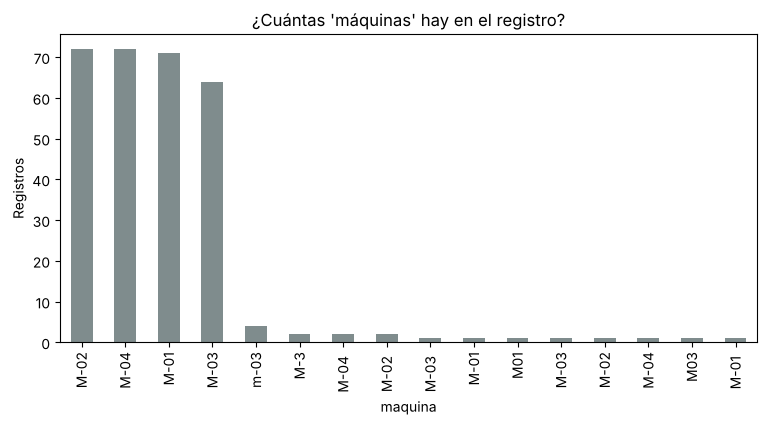

In [11]:
df["maquina"].value_counts().plot(kind="bar", color="#7f8c8d")
plt.title("¿Cuántas 'máquinas' hay en el registro?")
plt.ylabel("Registros")
plt.show()

✅ **Punto de control:** aparecen **16** "máquinas" distintas cuando solo existen 4. Para una persona, `M-03`, `m-03` y `M3` son la misma máquina; para la computadora son **textos distintos**. Hay incluso valores que se ven iguales pero tienen un espacio escondido al inicio o al final.

In [12]:
print("Valores distintos en 'turno':", df["turno"].nunique())
df["turno"].value_counts()

Valores distintos en 'turno': 12


turno
Noche      99
Tarde      92
Mañana     91
Tarde       3
 tarde      3
manana      2
Mañana      2
tarde       1
NOCHE       1
Manana      1
MAÑANA      1
mañana      1
Name: count, dtype: int64

✅ **Punto de control:** **12** formas de escribir 3 turnos.

### 3.4 Formato: ¿las fechas siguen el formato acordado?
El formato acordado es `aaaa-mm-dd` (por ejemplo, `2026-09-07`). Buscamos las fechas que traen una barra `/`, señal de que alguien escribió `dd/mm/aaaa`.

In [13]:
con_barra = df["fecha"].str.contains("/")            # 👉 True si la fecha tiene una "/"
print("Fechas en formato dd/mm/aaaa:", con_barra.sum())
df.loc[con_barra, "fecha"].head(6)

Fechas en formato dd/mm/aaaa: 30


4     07/09/2026
10    07/09/2026
38    10/09/2026
43    10/09/2026
49    11/09/2026
64    12/09/2026
Name: fecha, dtype: str

✅ **Punto de control:** **30** fechas escritas como `dd/mm/aaaa`.

### 3.5 Validez: ¿los valores son posibles?
Primero averiguamos **por qué** `temperatura` quedó como texto. `pd.to_numeric(..., errors="coerce")` intenta convertir cada valor a número; lo que no puede convertir lo deja vacío. Los valores que **no estaban vacíos** pero **no se pudieron convertir** son los culpables.

In [14]:
temp_como_numero = pd.to_numeric(df["temperatura"], errors="coerce")
no_es_numero = temp_como_numero.isna() & df["temperatura"].notna()     # 👉 tenía algo escrito, pero no es un número
print("Temperaturas que no son número:", no_es_numero.sum())
df.loc[no_es_numero, "temperatura"].head(8).tolist()

Temperaturas que no son número: 20


['43,4', '33,6', '31,4', '36,5', '31,9', '30,9', '32,1', '33,0']

✅ **Punto de control:** **20** temperaturas escritas con **coma decimal** (`36,5`). En Colombia usamos la coma para los decimales, pero Python usa el **punto**. Para Python, `36,5` no es un número.

Ahora revisamos las **reglas del negocio**. Cada regla es una condición que da `True` o `False` por fila; `sum()` cuenta cuántas filas la violan.

In [15]:
producidas = df["producidas"]
defectuosas = df["defectuosas"]

print("Producidas por encima de la capacidad (> 1.800):", (producidas > 1800).sum())
print("Defectuosas mayores que las producidas:         ", (defectuosas > producidas).sum())
print("Defectuosas negativas:                           ", (defectuosas < 0).sum())
print("Temperaturas por encima de 60 °C:                ", (temp_como_numero > 60).sum())

Producidas por encima de la capacidad (> 1.800): 2
Defectuosas mayores que las producidas:          3
Defectuosas negativas:                            2
Temperaturas por encima de 60 °C:                 14


✅ **Punto de control:** 2 por encima de la capacidad, 3 con más defectuosas que producidas, 2 negativas y **14** temperaturas por encima de 60 °C. Ninguna máquina de la planta trabaja a 95 °C: sospechamos que esas lecturas están en **grados Fahrenheit**.

### 3.6 El reporte de calidad
Juntamos todo en un **indicador por dimensión**, de 0 a 100 %. Lo escribimos como una **función**: un bloque de código con nombre que podemos volver a usar. La usaremos ahora (antes) y al final (después), y así la comparación será justa porque mide exactamente lo mismo.

`def` define la función; lo que va entre paréntesis (`tabla`) es el dato que recibe, y `return` es lo que entrega.

In [16]:
MAQUINAS_VALIDAS = ["M-01", "M-02", "M-03", "M-04"]
TURNOS_VALIDOS = ["Mañana", "Tarde", "Noche"]


def reporte_calidad(tabla):
    """Devuelve el % de filas que cumple cada dimensión de calidad."""
    prod = pd.to_numeric(tabla["producidas"], errors="coerce")
    defe = pd.to_numeric(tabla["defectuosas"], errors="coerce")
    temp = pd.to_numeric(tabla["temperatura"], errors="coerce")
    cumple_reglas = prod.between(1, 1800) & defe.between(0, prod) & temp.between(15, 60)

    medidas = {
        "Completitud": tabla.notna().all(axis=1).mean(),          # filas sin ningún vacío
        "Unicidad": (~tabla.duplicated()).mean(),                  # filas que no son copia
        "Consistencia": (tabla["maquina"].isin(MAQUINAS_VALIDAS)
                         & tabla["turno"].isin(TURNOS_VALIDOS)).mean(),
        "Formato": tabla["fecha"].astype(str).str.fullmatch(r"\d{4}-\d{2}-\d{2}").mean(),
        "Validez": cumple_reglas.mean(),                           # un vacío no cumple
    }
    return (pd.Series(medidas) * 100).round(1)


calidad_antes = reporte_calidad(df)       # 👉 medimos el original
calidad_antes

Completitud     94.6
Unicidad        97.0
Consistencia    88.9
Formato         89.9
Validez         80.8
dtype: float64

`mean()` sobre una columna de `True`/`False` da la **proporción** de `True`, porque Python cuenta `True` como 1 y `False` como 0. Multiplicada por 100 es un porcentaje.

🧠 **Responde:** ¿Qué dimensión está peor? Con estos datos, ¿confiarías en un informe de defectos por máquina? ¿Por qué?

Respuesta:* La peor es la **validez** (80,8 %), seguida de la consistencia (88,9 %) y el formato (89,9 %). No confiaría en un informe de defectos por máquina con estos datos: los duplicados inflan los totales, las máquinas mal escritas se cuentan como si fueran otras, y los valores imposibles cambian las tasas de defectos. Casi una de cada cinco filas viola alguna regla del negocio. Resumen del diagnóstico: 9 duplicados (unicidad), 10 defectuosas y 6 temperaturas vacías (completitud), 16 formas de escribir 4 máquinas y 12 de escribir 3 turnos (consistencia), 30 fechas dd/mm/aaaa (formato), y 20 temperaturas con coma, 14 en °F y 7 filas imposibles (validez).


## Parte 4 · Antes de limpiar: copia de trabajo y bitácora
Dos buenas prácticas que usa cualquier equipo de datos serio:

1. **Nunca limpies sobre el original.** Trabajamos sobre una **copia**, `limpio`. Si algo sale mal, `df` sigue intacto y se puede empezar de nuevo.
2. **Deja constancia de cada paso** en una **bitácora**: qué hiciste, cuántas filas había antes y cuántas quedaron. Eso se llama **trazabilidad**: cualquier persona puede revisar y repetir tu limpieza, y tú puedes defender tus números.

In [17]:
limpio = df.copy()      # 👉 copia de trabajo: todo lo que sigue se hace sobre 'limpio'
bitacora = []           # lista vacía donde iremos anotando cada paso


def registrar(paso, accion, filas_antes, filas_despues, valores_corregidos=0):
    """Anota un paso de limpieza en la bitácora y lo muestra."""
    bitacora[:] = [b for b in bitacora if b["paso"] != paso]     # si re-ejecutas la celda, no se repite
    bitacora.append({
        "paso": paso, "acción": accion,
        "filas antes": filas_antes, "filas después": filas_despues,
        "filas eliminadas": filas_antes - filas_despues,
        "valores corregidos": valores_corregidos,
    })
    print(f"📒 {paso}: {accion} | filas {filas_antes} → {filas_despues} | valores corregidos: {valores_corregidos}")


print("Copia lista:", limpio.shape)

Copia lista: (297, 6)


## Parte 5 · Paso 1 de limpieza: duplicados (unicidad)
**¿Por qué aparecen?** Alguien digitó dos veces el mismo turno, o copió y pegó un bloque de filas.

**¿Por qué hacen daño?** Una fila repetida **cuenta dos veces** la producción y los defectos de ese turno. Cualquier suma o promedio queda inflado.

`drop_duplicates()` deja **una** copia de cada fila repetida. Después usamos `reset_index(drop=True)` para renumerar las filas de 0 en adelante, sin huecos.

In [18]:
antes = len(limpio)
limpio = limpio.drop_duplicates().reset_index(drop=True)      # 👉 quita las copias exactas
registrar("Paso 1", "Quitar filas duplicadas", antes, len(limpio))

📒 Paso 1: Quitar filas duplicadas | filas 297 → 288 | valores corregidos: 0


✅ **Punto de control:** 297 → **288** filas. Coincide con 4 semanas × 6 días × 3 turnos × 4 máquinas.

🧠 **Responde:** ¿por qué conviene quitar los duplicados **antes** de sumar la producción y no después?

Respuesta:* Porque si sumo primero, los turnos repetidos se cuentan dos veces y la producción y los defectos quedan inflados. Después de sumar ya no se puede saber qué parte del total viene de filas repetidas.


## Parte 6 · Paso 2 de limpieza: textos inconsistentes (consistencia)
### 6.1 Las máquinas
Primero vemos **exactamente** cómo está escrito cada valor. Al imprimir una lista, Python pone cada texto entre comillas, y así se ven los espacios escondidos, como `' M-03'`.

In [19]:
print(sorted(limpio["maquina"].unique()))       # unique() = los valores distintos; sorted() los ordena

[' M-01', ' M-02', ' M-03', ' M-04', 'M-01', 'M-01 ', 'M-02', 'M-02 ', 'M-03', 'M-03 ', 'M-04', 'M-04 ', 'M-3', 'M01', 'M03', 'm-03']


Lo arreglamos en **dos pasos**:

**A. Quitar espacios y unificar mayúsculas.** Ya conoces estos métodos del 26 de septiembre: `strip()` quita los espacios del inicio y del final y `upper()` pasa a mayúsculas. En pandas se usan con `.str` delante, para aplicarlos a **cada** valor de la columna.

In [20]:
maquina_original = limpio["maquina"].copy()       # guardamos cómo estaba, para contar los cambios

limpio["maquina"] = limpio["maquina"].str.strip().str.upper()     # 👉
limpio["maquina"].value_counts()

maquina
M-02    72
M-04    72
M-01    71
M-03    69
M-3      2
M01      1
M03      1
Name: count, dtype: int64

Quedan formas como `M03` o `M-3`, que `strip()` y `upper()` no pueden arreglar.

**B. Diccionario de homologación.** *Homologar* es llevar todas las formas de escribir algo a **una sola forma oficial**. Un **diccionario** de Python (`{ }`) guarda parejas `"forma mal escrita": "forma oficial"`, y `replace()` cambia cada forma por su versión oficial. Incluimos todas las variantes posibles, aunque alguna no aparezca hoy: el diccionario queda listo para los datos de la próxima semana.

In [21]:
homologar_maquina = {
    "M01": "M-01", "M02": "M-02", "M03": "M-03", "M04": "M-04",
    "M-1": "M-01", "M-2": "M-02", "M-3": "M-03", "M-4": "M-04",
}
limpio["maquina"] = limpio["maquina"].replace(homologar_maquina)     # 👉

cambios_maquina = (limpio["maquina"] != maquina_original).sum()
print("Valores corregidos:", cambios_maquina)
limpio["maquina"].value_counts()

Valores corregidos: 18


maquina
M-01    72
M-02    72
M-03    72
M-04    72
Name: count, dtype: int64

✅ **Punto de control:** **4** máquinas y **18** valores corregidos.

### 6.2 Los turnos
Mismo problema, otra herramienta: `capitalize()` deja la **primera letra en mayúscula y el resto en minúscula** (`TARDE` → `Tarde`). Pero hay quien escribió `Manana` sin ñ, y eso solo lo arregla un diccionario.

In [22]:
print("Antes:", sorted(limpio["turno"].unique()))
turno_original = limpio["turno"].copy()

limpio["turno"] = limpio["turno"].str.strip().str.capitalize()     # 👉 quita espacios y unifica mayúsculas
limpio["turno"] = limpio["turno"].replace({"Manana": "Mañana"})     # 👉 recupera la ñ

cambios_turno = (limpio["turno"] != turno_original).sum()
print("Después:", sorted(limpio["turno"].unique()))
print("Valores corregidos:", cambios_turno)

Antes: [' tarde', 'MAÑANA', 'Manana', 'Mañana', 'Mañana ', 'NOCHE', 'Noche', 'Tarde', 'Tarde ', 'manana ', 'mañana', 'tarde']
Después: ['Mañana', 'Noche', 'Tarde']
Valores corregidos: 15


✅ **Punto de control:** 3 turnos y **15** valores corregidos.

Al homologar, dos filas que antes se veían distintas (`m-01` y `M-01`) pueden quedar **iguales**. Por eso, después de homologar, se vuelve a revisar si aparecieron duplicados nuevos:

In [23]:
print("Duplicados después de homologar:", limpio.duplicated().sum())

registrar("Paso 2", "Homologar máquinas y turnos", len(limpio), len(limpio), cambios_maquina + cambios_turno)

Duplicados después de homologar: 0
📒 Paso 2: Homologar máquinas y turnos | filas 288 → 288 | valores corregidos: 33


🧠 **Responde:** ¿por qué `M-03` y ` m-03` significan lo mismo para una persona pero son distintos para la computadora? ¿Qué le habría pasado a un gráfico por máquina si no homologamos?

Respuesta:* Porque la computadora compara los textos carácter por carácter: una minúscula o un espacio al inicio hacen que sea un texto diferente. Si no homologamos, el gráfico por máquina mostraría 16 barras en lugar de 4 y los datos de cada máquina quedarían repartidos, así que las tasas de defectos estarían mal.


## Parte 7 · Paso 3 de limpieza: tipos de datos (formato)
### 7.1 La temperatura, guardada como texto
El arreglo tiene dos movimientos:

1. `str.replace(",", ".")` cambia la coma decimal por punto: `"36,5"` → `"36.5"`.
2. `pd.to_numeric(..., errors="coerce")` convierte el texto en número. Con `errors="coerce"`, lo que no se pueda convertir queda **vacío** en lugar de detener el programa con un error.

(El `astype(str)` asegura que la columna sea texto antes de reemplazar; así la celda no falla si la ejecutas dos veces.)

Ese `coerce` es cómodo pero peligroso: podría **vaciar** datos sin avisar. Por eso contamos los vacíos **antes** y **después**. Si el número no cambia, no perdimos nada.

In [24]:
vacios_antes = limpio["temperatura"].isna().sum()

limpio["temperatura"] = pd.to_numeric(
    limpio["temperatura"].astype(str).str.replace(",", ".", regex=False),   # 👉 coma decimal → punto
    errors="coerce",                                                # 👉 texto → número
)

vacios_despues = limpio["temperatura"].isna().sum()
print("Vacíos antes:", vacios_antes, "| vacíos después:", vacios_despues)
print("Tipo de la columna ahora:", limpio["temperatura"].dtype)

Vacíos antes: 6 | vacíos después: 6
Tipo de la columna ahora: float64


✅ **Punto de control:** vacíos antes = vacíos después = **6**, y el tipo es `float64`. La conversión no perdió ningún dato.

### 7.2 Las fechas, en dos formatos
La tabla mezcla `2026-09-07` y `07/09/2026`. Es tentador escribir solo `pd.to_datetime(limpio["fecha"])` y dejar que pandas adivine, pero **adivinar es peligroso**: `07/09/2026` puede leerse como 7 de septiembre (costumbre colombiana) o como 9 de julio (costumbre de Estados Unidos). Si pandas elige mal, **no avisa**: la fecha queda equivocada y el análisis también.

Lo seguro es convertir **formato por formato**, diciéndole a pandas exactamente qué esperar:

- `format="%Y-%m-%d"` significa año‑mes‑día; `format="%d/%m/%Y"` significa día/mes/año.
- Cada conversión entiende solo **su** formato; las demás fechas quedan vacías (`NaT`, *Not a Time*).
- `fillna()` **rellena** los vacíos de la primera con los valores de la segunda.

In [25]:
formato_iso = pd.to_datetime(limpio["fecha"], format="%Y-%m-%d", errors="coerce")    # entiende 2026-09-07
formato_dmy = pd.to_datetime(limpio["fecha"], format="%d/%m/%Y", errors="coerce")    # entiende 07/09/2026

print("Entendidas como aaaa-mm-dd:", formato_iso.notna().sum())
print("Entendidas como dd/mm/aaaa:", formato_dmy.notna().sum())

limpio["fecha"] = formato_iso.fillna(formato_dmy)       # 👉 una sola columna de fechas reales
print("Fechas sin convertir:", limpio["fecha"].isna().sum())
print("Desde", limpio["fecha"].min().date(), "hasta", limpio["fecha"].max().date())

Entendidas como aaaa-mm-dd: 258
Entendidas como dd/mm/aaaa: 30
Fechas sin convertir: 0
Desde 2026-09-07 hasta 2026-10-03


✅ **Punto de control:** 258 + 30 = 288 fechas, **0** sin convertir, desde el **2026‑09‑07** hasta el **2026‑10‑03**. Si alguna fecha hubiera quedado fuera de ese rango, sería señal de que se leyó al revés.

Con fechas reales ya podemos hacer cosas que con texto no se puede, como saber qué día de la semana fue:

In [26]:
limpio["fecha"].dt.day_name().value_counts()     # .dt da acceso a las partes de una fecha

fecha
Monday       48
Tuesday      48
Wednesday    48
Thursday     48
Friday       48
Saturday     48
Name: count, dtype: int64

✅ **Punto de control:** 6 días (de lunes a sábado), 48 registros cada uno. No hay domingos, como debe ser.

In [27]:
registrar("Paso 3", "Temperatura a número y fechas a un solo formato", len(limpio), len(limpio),
          int(no_es_numero.sum()) + int(con_barra.sum()))

📒 Paso 3: Temperatura a número y fechas a un solo formato | filas 288 → 288 | valores corregidos: 50


🧠 **Responde:** si la computadora hubiera leído `07/09/2026` como 9 de julio, ¿qué le habría pasado al análisis? ¿Te habrías dado cuenta mirando la tabla?

Respuesta:* Esas fechas quedarían en julio, fuera del periodo real del registro, y los análisis por fecha, por semana o por día de la semana saldrían equivocados. Mirando la tabla probablemente no me daría cuenta, porque la fecha se ve normal; solo revisando el rango (mínimo y máximo) se notaría.


## Parte 8 · Paso 4 de limpieza: unidades (°F → °C)
Algunos supervisores copiaron la temperatura de un termómetro que marca en **grados Fahrenheit**. Un histograma lo delata: muestra cuántos registros caen en cada rango de temperatura.

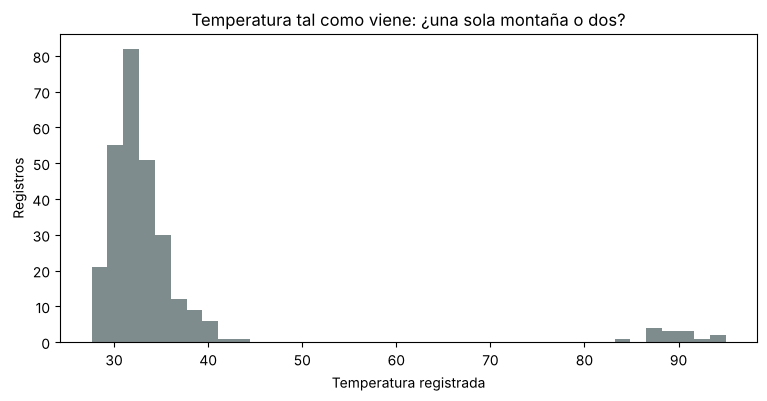

In [28]:
limpio["temperatura"].plot(kind="hist", bins=40, color="#7f8c8d")
plt.title("Temperatura tal como viene: ¿una sola montaña o dos?")
plt.xlabel("Temperatura registrada")
plt.ylabel("Registros")
plt.show()

Hay **dos montañas**: la grande, entre 28 y 44, es la temperatura en °C; la pequeña, entre 85 y 95, son temperaturas de la misma planta pero escritas en °F. La regla del negocio dice que el sensor mide como máximo 60 °C, así que **todo valor por encima de 60 está en Fahrenheit**.

La fórmula de conversión es **°C = (°F − 32) × 5 / 9**. Con `.loc[filas, columna]` cambiamos **solo** las filas marcadas, sin tocar las demás.

In [29]:
en_fahrenheit = limpio["temperatura"] > 60
print("Lecturas en °F:", en_fahrenheit.sum())
print("Ejemplos antes:", limpio.loc[en_fahrenheit, "temperatura"].head(5).tolist())

limpio.loc[en_fahrenheit, "temperatura"] = (
    (limpio.loc[en_fahrenheit, "temperatura"] - 32) * 5 / 9                    # 👉 °F → °C
).round(1)

print("Ejemplos después:", limpio.loc[en_fahrenheit, "temperatura"].head(5).tolist())

Lecturas en °F: 14
Ejemplos antes: [90.1, 94.8, 87.3, 95.0, 88.0]
Ejemplos después: [32.3, 34.9, 30.7, 35.0, 31.1]


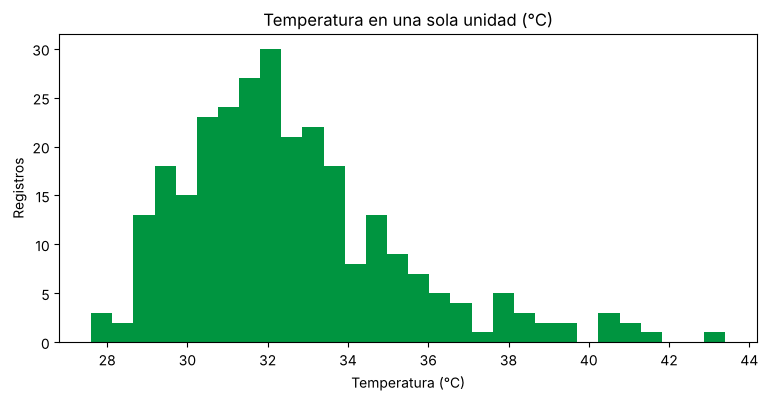

📒 Paso 4: Convertir lecturas en °F a °C | filas 288 → 288 | valores corregidos: 14


In [30]:
limpio["temperatura"].plot(kind="hist", bins=30, color="#009540")
plt.title("Temperatura en una sola unidad (°C)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Registros")
plt.show()

registrar("Paso 4", "Convertir lecturas en °F a °C", len(limpio), len(limpio), int(en_fahrenheit.sum()))

✅ **Punto de control:** **14** lecturas convertidas y una sola montaña, entre unos 28 y 44 °C.

🧠 **Responde:** ¿cómo delató el histograma que había dos unidades mezcladas? Si hubieras calculado el promedio de temperatura sin convertir, ¿habría salido más alto o más bajo que el real?

Respuesta:* El histograma mostró dos grupos separados: uno grande entre 28 y 44 (°C) y otro pequeño entre 85 y 95 (°F), con un hueco en el medio. Una misma planta no debería tener dos grupos tan separados. Si hubiera calculado el promedio sin convertir, habría salido **más alto** que el real, porque los valores en °F son mucho mayores.


## Parte 9 · Paso 5 de limpieza: datos faltantes (completitud)
Frente a un dato que falta hay dos caminos, y elegir bien es una **decisión de analista**, no de programación:

| Estrategia | Qué hace | Cuándo conviene |
|---|---|---|
| **Eliminar** la fila | Se pierde ese registro completo | Cuando falta la variable que se quiere analizar, o son pocas filas |
| **Imputar** (rellenar) | Se estima un valor razonable | Cuando falta una variable de apoyo y eliminar haría perder información útil |

**Nuestras dos decisiones:**

- **`defectuosas` vacía → eliminar.** Es justamente lo que queremos medir. Si la rellenamos con un promedio, estaríamos **inventando** defectos y la tasa de esa máquina dejaría de ser real.
- **`temperatura` vacía → imputar con la mediana de esa misma máquina.** La temperatura es una variable de apoyo. Usamos la **mediana** (el valor del medio) porque no se deja arrastrar por los valores extremos, y la calculamos **por máquina** porque cada máquina trabaja a su propia temperatura.

In [31]:
limpio.isnull().sum()       # ¿cuántos vacíos quedan?

fecha           0
turno           0
maquina         0
producidas      0
defectuosas    10
temperatura     6
dtype: int64

In [32]:
antes = len(limpio)
limpio = limpio.dropna(subset=["defectuosas"]).reset_index(drop=True)     # 👉 elimina filas sin defectuosas
registrar("Paso 5a", "Eliminar filas sin dato de defectuosas", antes, len(limpio))

📒 Paso 5a: Eliminar filas sin dato de defectuosas | filas 288 → 278 | valores corregidos: 0


✅ **Punto de control:** 288 → **278** filas.

Antes de imputar, miramos qué valor recibiría cada máquina. `groupby("maquina")` **agrupa** las filas por máquina, y `median()` calcula la mediana de cada grupo:

In [33]:
limpio.groupby("maquina")["temperatura"].median()

maquina
M-01    32.7
M-02    31.8
M-03    34.8
M-04    30.9
Name: temperatura, dtype: float64

Para rellenar, `transform("median")` repite la mediana de cada máquina en **todas sus filas**, de modo que cada vacío recibe la mediana de **su** máquina. Además, marcamos en una columna nueva qué temperaturas fueron imputadas: un dato estimado nunca debe confundirse con un dato medido.

In [34]:
if "temp_imputada" not in limpio.columns:                       # solo la primera vez (por si re-ejecutas la celda)
    limpio["temp_imputada"] = limpio["temperatura"].isna()      # True en las filas que vamos a rellenar

mediana_por_maquina = limpio.groupby("maquina")["temperatura"].transform("median")
limpio["temperatura"] = limpio["temperatura"].fillna(mediana_por_maquina)     # 👉 imputar

print("Temperaturas imputadas:", limpio["temp_imputada"].sum())
print("Vacíos que quedan en toda la tabla:", limpio.isnull().sum().sum())
limpio[limpio["temp_imputada"]]

Temperaturas imputadas: 6
Vacíos que quedan en toda la tabla: 0


,fecha,turno,maquina,producidas,defectuosas,temperatura,temp_imputada
0,2026-09-07,Mañana,M-02,1085,16.0,31.8,True
18,2026-09-08,Tarde,M-04,1198,6.0,30.9,True
58,2026-09-12,Mañana,M-01,1189,21.0,32.7,True
123,2026-09-18,Noche,M-02,1328,23.0,31.8,True
169,2026-09-23,Noche,M-01,1230,22.0,32.7,True
179,2026-09-24,Tarde,M-04,1274,22.0,30.9,True


In [35]:
registrar("Paso 5b", "Imputar temperatura con la mediana de su máquina", len(limpio), len(limpio),
          int(limpio["temp_imputada"].sum()))

📒 Paso 5b: Imputar temperatura con la mediana de su máquina | filas 278 → 278 | valores corregidos: 6


🧠 **Responde:** ¿por qué **no** rellenamos las defectuosas faltantes con el promedio? ¿Y por qué la mediana **por máquina** y no la mediana de toda la planta?

Respuesta:* Porque las defectuosas son justamente lo que queremos medir; si las rellenamos con un promedio estaríamos inventando defectos y la tasa de esa máquina ya no sería real. Usamos la mediana por máquina porque cada máquina trabaja a su propia temperatura (por ejemplo, la M-03 es más caliente que la M-04), y una mediana de toda la planta le pondría a una máquina una temperatura que no es la suya.


## Parte 10 · Paso 6 de limpieza: imposibles y atípicos (validez)
Dos conceptos que se confunden a menudo:

| | **Dato imposible** | **Dato atípico** (*outlier*) |
|---|---|---|
| Qué es | Viola una regla física o del negocio | Es raro, lejano a los demás, pero **posible** |
| Ejemplo | 12.000 unidades en una máquina de 1.800 | Una temperatura de 41 °C en un día muy caluroso |
| Qué se hace | Se elimina, o se corrige en la fuente | Se **investiga**: puede ser la noticia más importante |

### 10.1 Los imposibles, con las reglas del negocio
Cada regla es una condición. Primero **miramos** las filas que la violan y después decidimos.

In [36]:
sobre_capacidad = limpio["producidas"] > 1800
limpio[sobre_capacidad]

,fecha,turno,maquina,producidas,defectuosas,temperatura,temp_imputada
86,2026-09-15,Tarde,M-02,11320,16.0,33.7,False
170,2026-09-23,Noche,M-02,10770,19.0,29.9,False


🧠 **Responde:** compara esas producciones con las normales (unas 1.200). ¿Qué error de digitación crees que ocurrió?

Respuesta:* Parece que se digitó un cero de más: por ejemplo, 1.132 unidades se escribieron como 11.320 y 1.077 como 10.770.


In [37]:
invertidas = limpio["defectuosas"] > limpio["producidas"]
limpio[invertidas]

,fecha,turno,maquina,producidas,defectuosas,temperatura,temp_imputada
42,2026-09-10,Noche,M-01,16,959.0,32.3,False
137,2026-09-21,Mañana,M-01,25,1303.0,32.6,False
228,2026-09-29,Noche,M-01,18,1295.0,32.2,False


🧠 **Responde:** mira los números de `producidas` y `defectuosas` en esas filas. ¿Qué crees que pasó al digitarlas?

Respuesta:* Se intercambiaron las columnas: el número de producidas se escribió en defectuosas y el de defectuosas en producidas (por ejemplo, 16 producidas y 959 defectuosas debería ser al revés).


In [38]:
negativas = limpio["defectuosas"] < 0
limpio[negativas]

,fecha,turno,maquina,producidas,defectuosas,temperatura,temp_imputada
128,2026-09-19,Mañana,M-03,984,-35.0,34.4,False
167,2026-09-23,Tarde,M-03,1299,-67.0,37.7,False


Podríamos intentar corregir estas filas (quitar el cero de más, intercambiar las columnas, quitar el signo), pero **adivinar la corrección también es inventar datos**. Lo correcto en la planta sería preguntarle al supervisor. Como hoy no podemos, las **eliminamos** y lo dejamos anotado en la bitácora.

El símbolo `|` significa **o**: la fila es imposible si viola **cualquiera** de las tres reglas. El símbolo `~` significa **no**: nos quedamos con las filas que **no** son imposibles.

In [39]:
imposible = sobre_capacidad | invertidas | negativas
print("Filas imposibles:", imposible.sum())

antes = len(limpio)
limpio = limpio[~imposible].reset_index(drop=True)              # 👉 nos quedamos con las posibles
limpio["producidas"] = limpio["producidas"].astype(int)          # ya sin vacíos, vuelven a ser enteros
limpio["defectuosas"] = limpio["defectuosas"].astype(int)
registrar("Paso 6", "Eliminar filas que violan las reglas del negocio", antes, len(limpio))

Filas imposibles: 7
📒 Paso 6: Eliminar filas que violan las reglas del negocio | filas 278 → 271 | valores corregidos: 0


✅ **Punto de control:** **7** filas imposibles; quedan **271**.

### 10.2 Los atípicos, con el diagrama de caja y el rango intercuartílico (IQR)
Un **diagrama de caja** (*boxplot*) resume una columna: la caja va del **cuartil 1** (Q1, el 25 % de los datos está por debajo) al **cuartil 3** (Q3, el 75 % está por debajo), y la línea del medio es la mediana. Los puntos sueltos fuera de los "bigotes" son los **atípicos**.

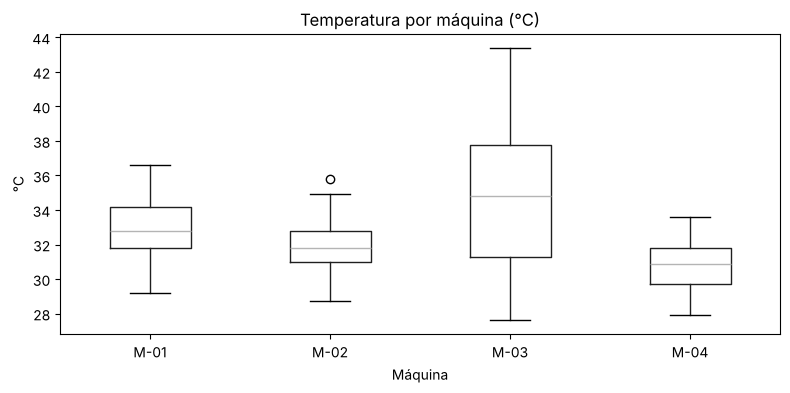

In [40]:
limpio.boxplot(column="temperatura", by="maquina", grid=False)
plt.suptitle("")                                # quita un título automático que pone pandas
plt.title("Temperatura por máquina (°C)")
plt.xlabel("Máquina")
plt.ylabel("°C")
plt.show()

La regla del **IQR** formaliza los bigotes:

- **IQR = Q3 − Q1**, el ancho de la caja.
- Es atípico todo valor por debajo de **Q1 − 1,5 × IQR** o por encima de **Q3 + 1,5 × IQR**.

In [41]:
q1 = limpio["temperatura"].quantile(0.25)
q3 = limpio["temperatura"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
print(f"Q1 = {q1:.1f} °C · Q3 = {q3:.1f} °C · IQR = {iqr:.1f} °C")
print(f"Límites: de {limite_inferior:.1f} a {limite_superior:.1f} °C")

es_atipico = (limpio["temperatura"] < limite_inferior) | (limpio["temperatura"] > limite_superior)    # 👉
atipicos = limpio[es_atipico]
print("Temperaturas atípicas:", len(atipicos))
atipicos[["fecha", "turno", "maquina", "temperatura", "producidas", "defectuosas"]]

Q1 = 30.7 °C · Q3 = 33.7 °C · IQR = 3.0 °C
Límites: de 26.2 a 38.2 °C
Temperaturas atípicas: 13


,fecha,turno,maquina,temperatura,producidas,defectuosas
1,2026-09-07,Mañana,M-03,39.0,1260,99
5,2026-09-07,Tarde,M-03,43.4,1298,171
17,2026-09-08,Tarde,M-03,40.8,1194,110
51,2026-09-11,Tarde,M-03,38.3,1020,60
63,2026-09-12,Tarde,M-03,40.6,1128,104
75,2026-09-14,Tarde,M-03,38.8,1128,68
96,2026-09-16,Tarde,M-03,39.6,1107,86
108,2026-09-17,Tarde,M-03,41.4,1116,125
118,2026-09-18,Tarde,M-03,40.8,1203,111
172,2026-09-24,Tarde,M-03,39.3,1156,84


¿Son errores? Lo comprobamos con la regla del sensor (15 a 60 °C) y miramos **dónde** ocurren:

In [42]:
print("Atípicos fuera del rango del sensor:", (~atipicos["temperatura"].between(15, 60)).sum())
print()
print(atipicos["maquina"].value_counts())
print()
print(atipicos["turno"].value_counts())

Atípicos fuera del rango del sensor: 0

maquina
M-03    13
Name: count, dtype: int64

turno
Tarde     12
Mañana     1
Name: count, dtype: int64


**Ningún** atípico está fuera del rango del sensor: son temperaturas **reales**, no errores. Y se concentran en una máquina y en un turno. Un atípico no se borra por ser raro: **atípico no es lo mismo que error**. Aquí, de hecho, es la primera pista para responder la pregunta del negocio.

🧠 **Responde:** ¿por qué **no** eliminamos los atípicos de temperatura? ¿Qué te dicen sobre la máquina y el turno donde aparecen?

Respuesta:* Porque están dentro del rango del sensor (15 a 60 °C), son temperaturas reales y no errores; borrarlas sería esconder la información más importante. Todas aparecen en la **M-03** y casi todas en el turno de la **tarde** (12 de 13), lo que indica que esa máquina se calienta demasiado en ese turno.


## Parte 11 · Medir otra vez: ¿mejoró la calidad?
Aplicamos la **misma** función de la Parte 3 a la tabla limpia y ponemos las dos mediciones lado a lado.

In [43]:
calidad_despues = reporte_calidad(limpio)                         # 👉 misma medición, tabla limpia
comparacion = pd.DataFrame({"Antes (%)": calidad_antes, "Después (%)": calidad_despues})
comparacion

,Antes (%),Después (%)
Completitud,94.6,100.0
Unicidad,97.0,100.0
Consistencia,88.9,100.0
Formato,89.9,100.0
Validez,80.8,100.0


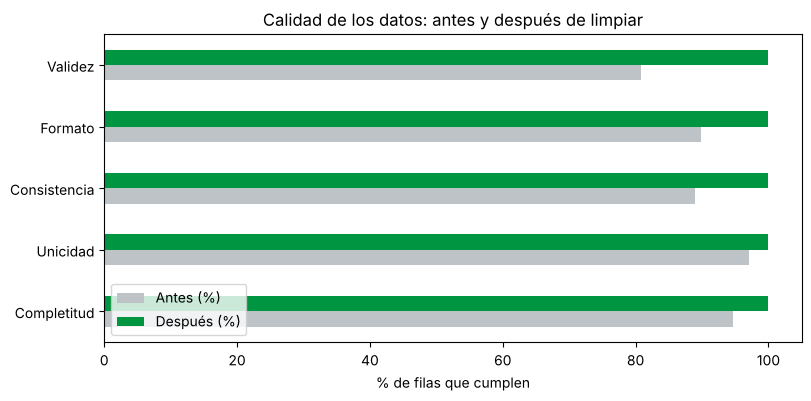

In [44]:
comparacion.plot(kind="barh", color=["#bdc3c7", "#009540"], xlim=(0, 105))
plt.title("Calidad de los datos: antes y después de limpiar")
plt.xlabel("% de filas que cumplen")
plt.legend(loc="lower left")
plt.show()

✅ **Punto de control:** las cinco dimensiones en **100 %**.

Y esta es la **bitácora** completa: la historia de la limpieza, paso a paso.

In [45]:
pd.DataFrame(bitacora)

,paso,acción,filas antes,filas después,filas eliminadas,valores corregidos
0,Paso 1,Quitar filas duplicadas,297,288,9,0
1,Paso 2,Homologar máquinas y turnos,288,288,0,33
2,Paso 3,Temperatura a número y fechas a un solo formato,288,288,0,50
3,Paso 4,Convertir lecturas en °F a °C,288,288,0,14
4,Paso 5a,Eliminar filas sin dato de defectuosas,288,278,10,0
5,Paso 5b,Imputar temperatura con la mediana de su máquina,278,278,0,6
6,Paso 6,Eliminar filas que violan las reglas del negocio,278,271,7,0


✅ **Punto de control:** se eliminaron 9 + 10 + 7 = **26** filas (297 → 271) y se corrigieron valores en las demás sin perderlas.

### ¿Y si no hubiéramos limpiado?
Hagamos el análisis "a la carrera", directamente sobre el original `df`: agrupar por máquina y calcular la **tasa de defectos** = defectuosas ÷ producidas × 100.

In [46]:
sucio = df.groupby("maquina")[["producidas", "defectuosas"]].sum()
sucio["tasa_%"] = (sucio["defectuosas"] / sucio["producidas"] * 100).round(2)
sucio.sort_values("tasa_%", ascending=False)

,producidas,defectuosas,tasa_%
maquina,,,
M-03,1128,104.0,9.22
M-03,1260,99.0,7.86
M-01,82600,4897.0,5.93
m-03,4403,247.0,5.61
M-3,2287,125.0,5.47
M-03,78125,2793.0,3.58
M03,909,32.0,3.52
M01,1229,36.0,2.93
M-02,1298,27.0,2.08


Fíjate en dos cosas: **cuántas filas** tiene esa tabla (¿cuántas "máquinas"?) y **en qué puesto** quedan `M-01` y `M-03`. Ahora, el mismo cálculo con los datos limpios:

In [47]:
por_maquina = limpio.groupby("maquina")[["producidas", "defectuosas"]].sum()
por_maquina["tasa_%"] = (por_maquina["defectuosas"] / por_maquina["producidas"] * 100).round(2)
por_maquina = por_maquina.sort_values("tasa_%", ascending=False)
por_maquina

,producidas,defectuosas,tasa_%
maquina,,,
M-03,81008,3475,4.29
M-01,80475,1389,1.73
M-02,81031,1302,1.61
M-04,80958,982,1.21


🧠 **Responde:** con los datos sucios, ¿a qué máquina habrías enviado a mantenimiento? ¿Y con los limpios? ¿Qué filas sucias crees que causaron la diferencia?

Respuesta:* Con los datos sucios habría enviado a mantenimiento a la **M-01**, que aparece con 5,93 %, la tasa más alta entre las máquinas bien escritas, mientras que la M-03 queda repartida en varias formas de escribirla (` M-03`, `m-03`, `M-3`...). Con los datos limpios, la peor es claramente la **M-03** con 4,29 %, y la M-01 baja a 1,73 % (la M-03 sin limpiar solo mostraba 3,58 % en su forma principal). Es decir, con el mismo archivo se llega a dos conclusiones opuestas: la calidad de los datos cambia la decisión. La diferencia la causaron las 3 filas de la M-01 con las columnas intercambiadas (más de 3.500 defectuosas falsas) y la M-03 dividida por no estar homologada.


## Parte 12 · Analizar con datos confiables
Ahora sí, con datos en los que podemos confiar, respondemos la pregunta de la gerencia.

### 12.1 La tasa de defectos de cada registro
Creamos una columna nueva con la tasa de cada fila. pandas hace la división **fila por fila** de una sola vez.

In [48]:
limpio["tasa_defectos"] = (limpio["defectuosas"] / limpio["producidas"] * 100).round(2)     # 👉
limpio.head()

,fecha,turno,maquina,producidas,defectuosas,temperatura,temp_imputada,tasa_defectos
0,2026-09-07,Mañana,M-02,1085,16,31.8,True,1.47
1,2026-09-07,Mañana,M-03,1260,99,39.0,False,7.86
2,2026-09-07,Mañana,M-04,1054,18,31.2,False,1.71
3,2026-09-07,Tarde,M-01,1062,20,35.4,False,1.88
4,2026-09-07,Tarde,M-02,1105,12,34.5,False,1.09


### 12.2 ¿Qué máquina?
La tasa de una máquina se calcula con los **totales**: todas sus defectuosas entre todas sus producidas. No se promedian las tasas de cada fila, porque un turno de 900 unidades pesaría igual que uno de 1.600.

Tasa de defectos de toda la planta: 2.21 %


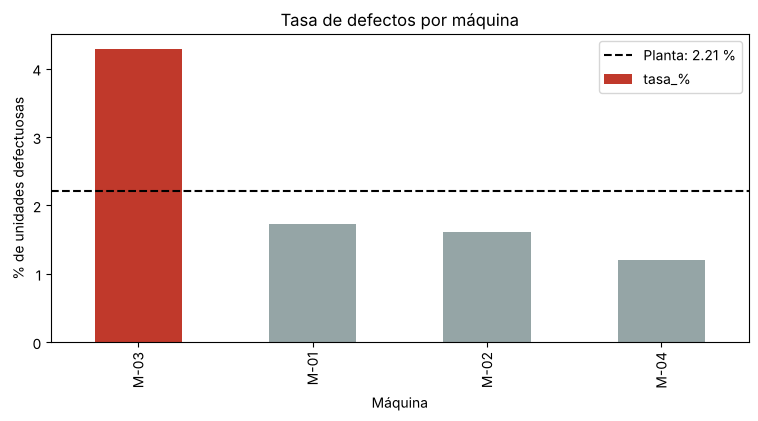

In [49]:
tasa_planta = limpio["defectuosas"].sum() / limpio["producidas"].sum() * 100
print(f"Tasa de defectos de toda la planta: {tasa_planta:.2f} %")

colores = ["#c0392b" if i == 0 else "#95a5a6" for i in range(len(por_maquina))]   # la peor, en rojo
ax = por_maquina["tasa_%"].plot(kind="bar", color=colores)
ax.axhline(tasa_planta, color="black", linestyle="--", label=f"Planta: {tasa_planta:.2f} %")
plt.title("Tasa de defectos por máquina")
plt.ylabel("% de unidades defectuosas")
plt.xlabel("Máquina")
plt.legend()
plt.show()

### 12.3 ¿Qué turno?

In [50]:
por_turno = limpio.groupby("turno")[["producidas", "defectuosas"]].sum()
por_turno["tasa_%"] = (por_turno["defectuosas"] / por_turno["producidas"] * 100).round(2)
por_turno = por_turno.loc[["Mañana", "Tarde", "Noche"]]          # en el orden del día
por_turno

,producidas,defectuosas,tasa_%
turno,,,
Mañana,106239,2179,2.05
Tarde,109413,2939,2.69
Noche,107820,2030,1.88


### 12.4 Máquina y turno a la vez
Una **tabla dinámica** (`pivot_table`), como la de Excel, cruza dos variables: máquinas en las filas, turnos en las columnas. Sumamos defectuosas y producidas en cada cruce y luego dividimos.

In [51]:
cruce = limpio.pivot_table(index="maquina", columns="turno",
                           values=["defectuosas", "producidas"], aggfunc="sum")
tasa_cruce = (cruce["defectuosas"] / cruce["producidas"] * 100).round(2)     # 👉
tasa_cruce = tasa_cruce[["Mañana", "Tarde", "Noche"]]
tasa_cruce

turno,Mañana,Tarde,Noche
maquina,,,
M-01,1.76,1.69,1.73
M-02,1.65,1.51,1.66
M-03,3.47,6.45,2.97
M-04,1.32,1.15,1.17


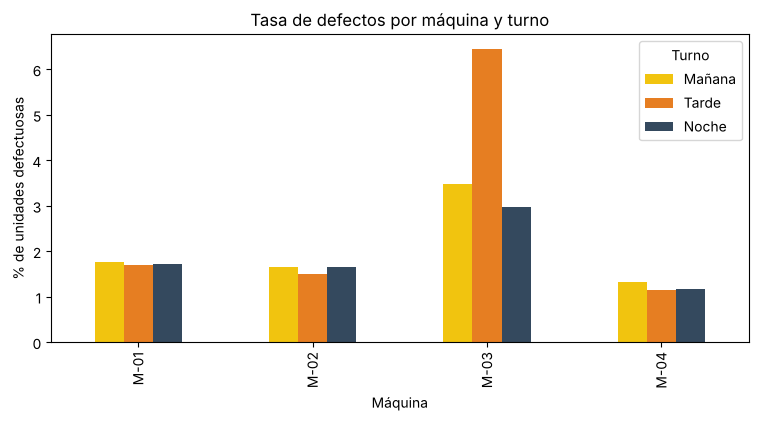

In [52]:
tasa_cruce.plot(kind="bar", color=["#f1c40f", "#e67e22", "#34495e"])
plt.title("Tasa de defectos por máquina y turno")
plt.ylabel("% de unidades defectuosas")
plt.xlabel("Máquina")
plt.legend(title="Turno")
plt.show()

### 12.5 ¿Tiene que ver el calor?
Un **diagrama de dispersión** pone un punto por registro: la temperatura en el eje horizontal y la tasa de defectos en el vertical. Si los puntos suben hacia la derecha, a más temperatura, más defectos.

La **correlación** resume esa relación en un número entre −1 y 1: cerca de 1, suben juntas; cerca de 0, no hay relación lineal; cerca de −1, una sube cuando la otra baja. Ojo: **correlación no es causalidad**. Que dos cosas suban juntas no prueba que una cause la otra, pero sí dice dónde investigar.

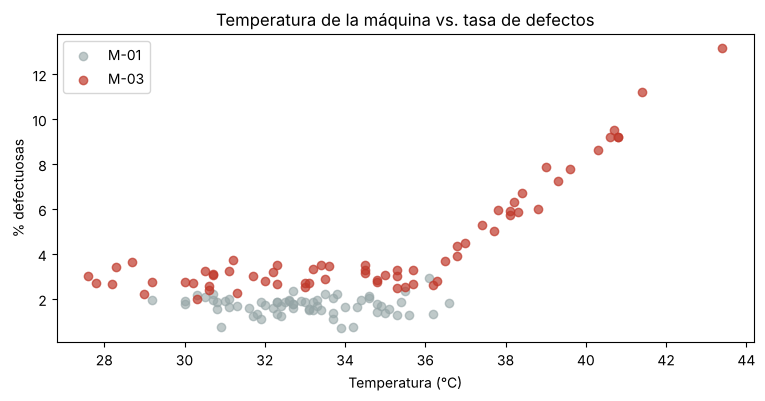

Correlación temperatura–defectos en M-03: 0.81
Correlación temperatura–defectos en M-01: -0.05


In [53]:
m03 = limpio[limpio["maquina"] == "M-03"]
m01 = limpio[limpio["maquina"] == "M-01"]

plt.scatter(m01["temperatura"], m01["tasa_defectos"], alpha=0.6, label="M-01", color="#95a5a6")
plt.scatter(m03["temperatura"], m03["tasa_defectos"], alpha=0.7, label="M-03", color="#c0392b")
plt.title("Temperatura de la máquina vs. tasa de defectos")
plt.xlabel("Temperatura (°C)")
plt.ylabel("% defectuosas")
plt.legend()
plt.show()

print("Correlación temperatura–defectos en M-03:", round(m03["temperatura"].corr(m03["tasa_defectos"]), 2))   # 👉
print("Correlación temperatura–defectos en M-01:", round(m01["temperatura"].corr(m01["tasa_defectos"]), 2))

🧠 **Responde:** ¿qué máquina y qué turno concentran los defectos? ¿Qué dice la correlación sobre la relación con la temperatura en la M‑03 y en la M‑01? Recuerda el año de instalación de cada máquina (Parte 1).
Respuesta:* La **M-03** concentra los defectos (4,29 %, casi el doble de la planta, 2,21 %) y el peor turno es la **tarde** (2,69 %). En el cruce, la M-03 en la tarde llega a **6,45 %**. En la M-03 la correlación entre temperatura y defectos es fuerte y positiva (0,81): cuanto más se calienta, más defectos produce. En la M-01 es casi cero (−0,05), no hay relación. Tiene sentido porque la M-03 es la máquina más vieja (instalada en 2012).


## Parte 13 · Guardar, concluir y entregar
### 13.1 Guardar la tabla limpia
`to_csv()` guarda el DataFrame como un archivo nuevo; `index=False` evita guardar la numeración de filas como una columna más. El original queda intacto, con su propio nombre.

In [54]:
limpio.to_csv("registro_produccion_limpio.csv", index=False)      # 👉
print("Archivo guardado: registro_produccion_limpio.csv")
print("Filas y columnas:", limpio.shape)

Archivo guardado: registro_produccion_limpio.csv
Filas y columnas: (271, 8)


✅ **Punto de control:** `(271, 8)`: las 6 columnas originales más `temp_imputada` y `tasa_defectos`.

En Colab, el archivo aparece en el panel **Archivos** (ícono de carpeta, a la izquierda); con clic derecho → **Descargar** lo guardas en tu computador. En VS Code queda en la misma carpeta del cuaderno.

### 13.2 Resumen de técnicas: tu hoja de referencia
| Problema | Dimensión | Técnica en pandas |
|---|---|---|
| Filas repetidas | Unicidad | `drop_duplicates()` |
| Espacios y mayúsculas | Consistencia | `.str.strip()`, `.str.upper()`, `.str.capitalize()` |
| Varias formas de escribir lo mismo | Consistencia | Diccionario + `replace()` |
| Números con coma decimal | Formato / validez | `.str.replace(",", ".")` + `pd.to_numeric(errors="coerce")` |
| Fechas en varios formatos | Formato | `pd.to_datetime(format=...)` por formato + `fillna()` |
| Unidades mezcladas | Validez | Regla del negocio + `.loc[...]` con la fórmula |
| Dato faltante clave | Completitud | `dropna(subset=[...])` |
| Dato faltante de apoyo | Completitud | `fillna()` con la mediana por grupo (`transform`) |
| Valor imposible | Validez | Reglas con `>`, `<`, `|` y filtro con `~` |
| Valor atípico | (investigar) | Boxplot + regla del IQR |

### 13.3 Tus conclusiones
Escribe como si se lo explicaras a la gerente de la planta, sin términos de programación.

🧠 **Responde:** escribe **tres hallazgos** respaldados por números del cuaderno (máquina, turno, temperatura).

Respuesta:* 1. La **M-03 (Selladora C)** tiene la mayor tasa de defectos: **4,29 %**, frente a 1,2 %–1,7 % de las demás máquinas y 2,21 % de toda la planta.
2. El problema es peor en el turno de la **tarde**: la M-03 llega a **6,45 %** de defectos en la tarde, contra 3,47 % en la mañana y 2,97 % en la noche.
3. Las 13 temperaturas atípicas (38 a 43 °C) son todas de la M-03 y 12 de ellas en la tarde; en esa máquina la temperatura y los defectos están muy relacionados (correlación de 0,81).


🧠 **Responde:** escribe **una recomendación**: ¿a qué máquina le harías mantenimiento primero y por qué?

Respuesta:* Le haría mantenimiento primero a la **M-03 (Selladora C)**, revisando su sistema de temperatura (resistencias, sensor y enfriamiento), porque se recalienta sobre todo en la tarde y ahí produce más defectos. Además es la máquina más antigua de la planta (2012).


🧠 **Responde:** ¿qué le propondrías a la planta para que el registro llegue más limpio desde el origen? (Piensa en los errores que encontraste hoy.)

Respuesta:* Cambiar la hoja de cálculo por un formulario con listas desplegables para máquina y turno, un selector de fecha con un solo formato, campos numéricos que solo acepten valores dentro de las reglas (0 a 1.800 unidades, defectuosas menores que las producidas, temperatura entre 15 y 60 °C) y que no dejen campos vacíos. También usar siempre el termómetro en °C, evitar que el mismo turno se registre dos veces y capacitar a los supervisores para digitar igual.


### 13.4 Lista de verificación antes de entregar
- [x] Ejecuté **todas** las celdas en orden, sin errores (si dudas: *Ejecutar todo*).
- [x] Mis puntos de control ✅ coinciden con los números indicados.
- [x] Respondí **todas** las preguntas 🧠, incluidas las tres conclusiones.

### 13.5 Cómo entregar en Moodle
1. Guarda el cuaderno con los resultados visibles.
   - **Colab:** Archivo → Descargar → Descargar .ipynb.
   - **VS Code:** guarda con Ctrl + S; el archivo `.ipynb` ya está en tu carpeta.
2. Entra al aula de **Ciencia de Datos** en Moodle → tarea **"Taller en clase · Semana 9"**.
3. Sube el archivo `.ipynb`. Si trabajaste en pareja, súbelo **cada uno** y escribe el nombre de tu compañero en la primera pregunta 🧠.

¡Buen trabajo! Hoy hiciste lo que más tiempo consume en un proyecto real de datos: dejar los datos listos para confiar en ellos.